In [ ]:
# 1. Install required libraries
!pip install -q transformers torch torchvision scikit-learn matplotlib seaborn pillow

In [ ]:
# 2. Import libraries
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from google.colab import files

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from transformers import AutoImageProcessor, CvtForImageClassification

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# 3. Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is not enabled. In Colab, use Runtime > Change runtime type > GPU.")

Device: cuda
GPU: Tesla T4


## 4. Upload the dataset ZIP

Upload your dataset ZIP file.

Expected ZIP structure:

```text
image_dataset/
├── train/
│   ├── Fake/
│   └── Real/
├── validation/
│   ├── Fake/
│   └── Real/
└── test/
    ├── Fake/
    └── Real/
```

In [ ]:
# 5. Upload ZIP file
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
print("Uploaded:", zip_name)

Saving image_dataset_new.zip to image_dataset_new.zip
Uploaded: image_dataset_new.zip


In [ ]:
# 6. Extract ZIP
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_name, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)

# Automatically find the folder containing train/validation/test
base_dir = None

for root, dirs, files_ in os.walk(extract_path):
    if all(x in dirs for x in ["train", "validation", "test"]):
        base_dir = root
        break

if base_dir is None:
    raise FileNotFoundError(
        "Could not find a folder containing train, validation and test folders."
    )

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "validation")
test_dir = os.path.join(base_dir, "test")

print("Base directory:", base_dir)
print("Train:", train_dir)
print("Validation:", val_dir)
print("Test:", test_dir)

Dataset extracted to: /content/dataset
Base directory: /content/dataset/image_dataset
Train: /content/dataset/image_dataset/train
Validation: /content/dataset/image_dataset/validation
Test: /content/dataset/image_dataset/test


In [ ]:
# 7. Check dataset class folders and image counts

def count_images(folder):
    result = {}
    for cls in sorted(os.listdir(folder)):
        cls_path = os.path.join(folder, cls)
        if os.path.isdir(cls_path):
            result[cls] = len([
                f for f in os.listdir(cls_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
            ])
    return result

print("TRAIN:", count_images(train_dir))
print("VALIDATION:", count_images(val_dir))
print("TEST:", count_images(test_dir))

TRAIN: {'Fake': 350, 'Real': 348}
VALIDATION: {'Fake': 75, 'Real': 75}
TEST: {'Fake': 75, 'Real': 74}


## 8. Load pretrained CvT-13

We use Microsoft's pretrained `cvt-13` model and replace the final classifier with **2 classes: Fake and Real**.

In [ ]:
# 8. Load CvT-13 processor
MODEL_NAME = "microsoft/cvt-13"

processor = AutoImageProcessor.from_pretrained(MODEL_NAME)

print("CvT-13 processor loaded.")
print("Image mean:", processor.image_mean)
print("Image std :", processor.image_std)

preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

CvT-13 processor loaded.
Image mean: (0.485, 0.456, 0.406)
Image std : (0.229, 0.224, 0.225)


In [ ]:
# 9. Image transformations
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=processor.image_mean,
        std=processor.image_std
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=processor.image_mean,
        std=processor.image_std
    )
])

print("Transforms ready.")

Transforms ready.


In [ ]:
# 10. Load datasets
train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    val_dir,
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=val_test_transform
)

print("Classes:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)

print("Training images  :", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images      :", len(test_dataset))

Classes: ['Fake', 'Real']
Class mapping: {'Fake': 0, 'Real': 1}
Training images  : 698
Validation images: 150
Test images      : 149


In [ ]:
# 11. DataLoaders
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created.")

DataLoaders created.


In [ ]:
# 12. Create CvT-13 model for 2 classes
id2label = {
    0: "Fake",
    1: "Real"
}

label2id = {
    "Fake": 0,
    "Real": 1
}

model = CvtForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

model = model.to(device)

print("CvT-13 model loaded successfully.")
print("Number of labels:", model.config.num_labels)

config.json:   0%|          | 0.00/70.3k [00:00<?, ?B/s]

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `1000`.


model.safetensors: reconstructing file:   0%|          |  0.00B / 80.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/459 [00:00<?, ?it/s]

[transformers] CvtForImageClassification LOAD REPORT from: microsoft/cvt-13
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 384]) vs model:torch.Size([2, 384])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


CvT-13 model loaded successfully.
Number of labels: 2


In [ ]:
# 13. Loss, optimizer and scheduler
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=0.01
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

print("Optimizer and scheduler ready.")

Optimizer and scheduler ready.


In [ ]:
print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

print("Classes:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)

Train dataset: 698
Validation dataset: 150
Test dataset: 149
Train batches: 44
Validation batches: 10
Test batches: 10
Classes: ['Fake', 'Real']
Class mapping: {'Fake': 0, 'Real': 1}


In [ ]:
images, labels = next(iter(train_loader))

print("Image shape:", images.shape)
print("Labels:", labels)
print("Image min:", images.min().item())
print("Image max:", images.max().item())

Image shape: torch.Size([16, 3, 224, 224])
Labels: tensor([1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1])
Image min: -2.1179039478302
Image max: 2.640000104904175


In [ ]:
print("Device:", device)
print("Model device:", next(model.parameters()).device)

print(
    "Trainable parameters:",
    sum(p.numel() for p in model.parameters() if p.requires_grad)
)

Device: cuda
Model device: cuda:0
Trainable parameters: 19613250


In [ ]:
# 14. Training function
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(pixel_values=images)
        loss = criterion(outputs.logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = torch.argmax(outputs.logits, dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [ ]:
# 15. Evaluation function
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(pixel_values=images)
            loss = criterion(outputs.logits, labels)

            probabilities = torch.softmax(outputs.logits, dim=1)
            predictions = torch.argmax(outputs.logits, dim=1)

            running_loss += loss.item() * images.size(0)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities[:, 1].cpu().numpy())

    loss = running_loss / total
    accuracy = correct / total

    return (
        loss,
        accuracy,
        np.array(all_labels),
        np.array(all_predictions),
        np.array(all_probabilities)
    )

In [ ]:
from PIL import Image


def test_images(folder):
    bad_images = []

    for root, dirs, files_ in os.walk(folder):
        for filename in files_:
            if filename.lower().endswith(
                (".jpg", ".jpeg", ".png", ".bmp", ".webp")
            ):
                path = os.path.join(root, filename)

                try:
                    with Image.open(path) as img:
                        img = img.convert("RGB")
                        img.load()

                except Exception as e:
                    bad_images.append((path, repr(e)))

    return bad_images


print("Testing TRAIN...")
bad_train = test_images(train_dir)

print("Testing VALIDATION...")
bad_val = test_images(val_dir)

print("Testing TEST...")
bad_test = test_images(test_dir)

print("\n========== RESULT ==========")
print("Bad train images:", len(bad_train))
print("Bad validation images:", len(bad_val))
print("Bad test images:", len(bad_test))

if bad_val:
    print("\nVALIDATION BAD IMAGES:")
    for x in bad_val:
        print(x)

Testing TRAIN...
Testing VALIDATION...
Testing TEST...

========== RESULT ==========
Bad train images: 0
Bad validation images: 0
Bad test images: 0


In [ ]:
# Remove corrupted images from train/validation
# Test set has no corrupted images.

import os

bad_files = bad_train + bad_val

print("Corrupted files found:", len(bad_files))

for path, error in bad_files:
    if os.path.exists(path):
        os.remove(path)
        print("Removed:", os.path.basename(path))

print("\nCorrupted images removed successfully.")

Corrupted files found: 0

Corrupted images removed successfully.


In [ ]:
print("========== CLEAN DATASET ==========")

print("TRAIN:", count_images(train_dir))
print("VALIDATION:", count_images(val_dir))
print("TEST:", count_images(test_dir))

print("\nTotal train:", len(train_dataset))
print("Total validation:", len(val_dataset))
print("Total test:", len(test_dataset))

========== CLEAN DATASET ==========
TRAIN: {'Fake': 350, 'Real': 341}
VALIDATION: {'Fake': 75, 'Real': 53}
TEST: {'Fake': 75, 'Real': 74}

Total train: 691
Total validation: 128
Total test: 149


In [ ]:
# Recreate datasets AFTER deleting corrupted images

train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    val_dir,
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=val_test_transform
)

print("========== NEW DATASET OBJECTS ==========")

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

print("\nTrain classes:", train_dataset.class_to_idx)
print("Val classes:", val_dataset.class_to_idx)
print("Test classes:", test_dataset.class_to_idx)

========== NEW DATASET OBJECTS ==========
Train: 691
Validation: 128
Test: 149

Train classes: {'Fake': 0, 'Real': 1}
Val classes: {'Fake': 0, 'Real': 1}
Test classes: {'Fake': 0, 'Real': 1}


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 44
Validation batches: 8
Test batches: 10


In [ ]:
val_loss, val_accuracy, val_labels, val_preds, val_probs = evaluate(
    model,
    val_loader,
    criterion,
    device
)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)
print("Correct:", (val_labels == val_preds).sum())
print("Total:", len(val_labels))

Validation Loss: 0.3348394073545933
Validation Accuracy: 0.9296875
Correct: 119
Total: 128


In [ ]:
EPOCHS = 10

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_accuracy = 0.0
best_model_path = "/content/best_cvt13_model.pth"

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    (
        val_loss,
        val_acc,
        val_labels,
        val_preds,
        val_probs
    ) = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_acc)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"LR: {current_lr:.2e}"
    )

    if val_acc > best_val_accuracy:

        best_val_accuracy = val_acc

        torch.save(
            model.state_dict(),
            best_model_path
        )

        print("   ✓ Best model saved.")

print("\nTraining completed.")
print("Best validation accuracy:", f"{best_val_accuracy:.4f}")

Epoch [01/10] | Train Loss: 0.3278 | Train Acc: 0.8654 | Val Loss: 0.1506 | Val Acc: 0.9766 | LR: 2.00e-05
   ✓ Best model saved.
Epoch [02/10] | Train Loss: 0.2534 | Train Acc: 0.8828 | Val Loss: 0.0905 | Val Acc: 0.9766 | LR: 2.00e-05
Epoch [03/10] | Train Loss: 0.1910 | Train Acc: 0.9030 | Val Loss: 0.0782 | Val Acc: 0.9766 | LR: 2.00e-05
Epoch [04/10] | Train Loss: 0.1804 | Train Acc: 0.8987 | Val Loss: 0.0836 | Val Acc: 0.9688 | LR: 1.00e-05
Epoch [05/10] | Train Loss: 0.1680 | Train Acc: 0.9103 | Val Loss: 0.0495 | Val Acc: 0.9766 | LR: 1.00e-05
Epoch [06/10] | Train Loss: 0.1736 | Train Acc: 0.8944 | Val Loss: 0.0451 | Val Acc: 0.9766 | LR: 1.00e-05
Epoch [07/10] | Train Loss: 0.1631 | Train Acc: 0.9045 | Val Loss: 0.0220 | Val Acc: 0.9922 | LR: 1.00e-05
   ✓ Best model saved.
Epoch [08/10] | Train Loss: 0.1590 | Train Acc: 0.8987 | Val Loss: 0.0291 | Val Acc: 0.9922 | LR: 1.00e-05
Epoch [09/10] | Train Loss: 0.1655 | Train Acc: 0.8900 | Val Loss: 0.0191 | Val Acc: 1.0000 | LR: 

## 16. Train CvT-13

For this relatively small dataset, start with **10 epochs**. The best validation model is saved automatically.

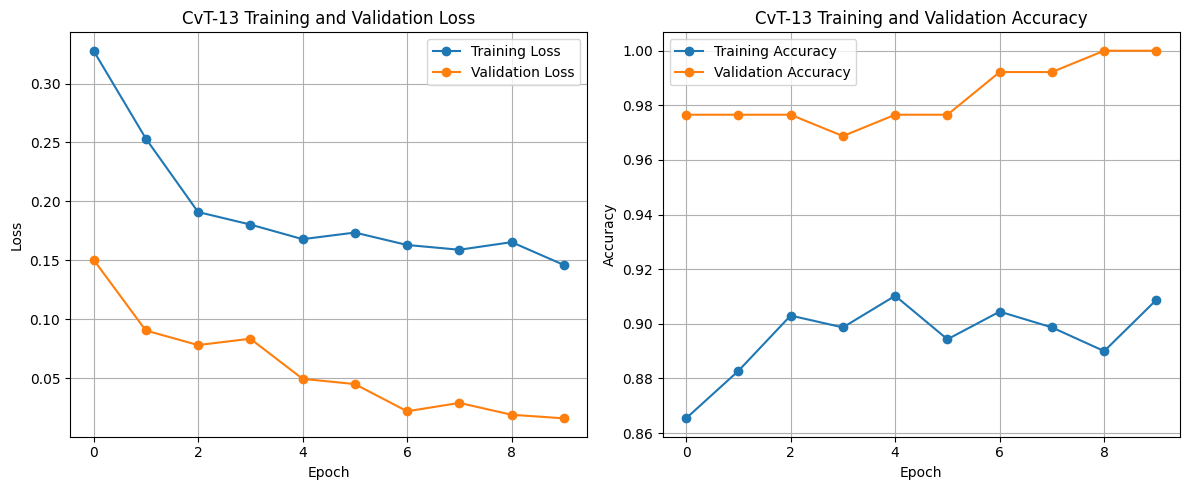

In [ ]:
# 17. Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, marker="o", label="Training Loss")
plt.plot(val_losses, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CvT-13 Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, marker="o", label="Training Accuracy")
plt.plot(val_accuracies, marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CvT-13 Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# 18. Load the best validation model
model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

model.to(device)

print("Best CvT-13 model loaded.")

Best CvT-13 model loaded.


## 19. Final Test Evaluation

In [ ]:
# 19. Evaluate on the untouched test set
(
    test_loss,
    test_accuracy,
    test_labels,
    test_predictions,
    test_probabilities
) = evaluate(
    model,
    test_loader,
    criterion,
    device
)

precision = precision_score(
    test_labels,
    test_predictions,
    pos_label=1,
    zero_division=0
)

recall = recall_score(
    test_labels,
    test_predictions,
    pos_label=1,
    zero_division=0
)

f1 = f1_score(
    test_labels,
    test_predictions,
    pos_label=1,
    zero_division=0
)

print("========== CvT-13 TEST RESULTS ==========")
print(f"Test Loss : {test_loss:.4f}")
print(f"Accuracy  : {test_accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

========== CvT-13 TEST RESULTS ==========
Test Loss : 0.0260
Accuracy  : 0.9933
Precision : 1.0000
Recall    : 0.9865
F1 Score  : 0.9932


In [ ]:
# 20. Classification report
print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=["Fake", "Real"],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        Fake     0.9868    1.0000    0.9934        75
        Real     1.0000    0.9865    0.9932        74

    accuracy                         0.9933       149
   macro avg     0.9934    0.9932    0.9933       149
weighted avg     0.9934    0.9933    0.9933       149



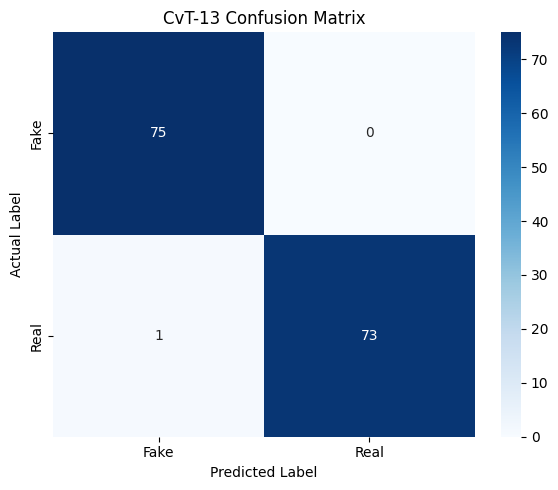

In [ ]:
# 21. Confusion Matrix
cm = confusion_matrix(
    test_labels,
    test_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("CvT-13 Confusion Matrix")

plt.tight_layout()
plt.show()

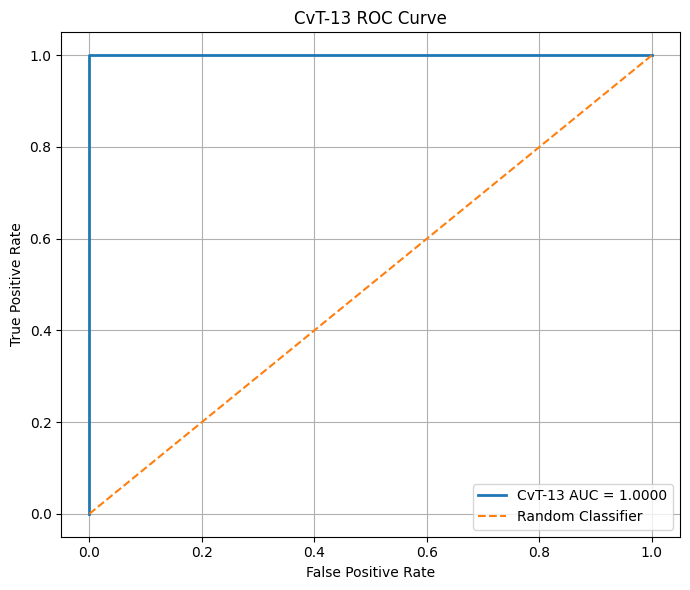

ROC-AUC: 1.0000


In [ ]:
# 22. ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(
    test_labels,
    test_probabilities
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"CvT-13 AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CvT-13 ROC Curve")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("ROC-AUC:", f"{roc_auc:.4f}")

In [ ]:
# 23. Final results summary table
results = pd.DataFrame({
    "Metric": [
        "Best Validation Accuracy",
        "Test Loss",
        "Test Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        best_val_accuracy,
        test_loss,
        test_accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

results["Score"] = results["Score"].round(4)

display(results)

,Metric,Score
0,Best Validation Accuracy,1.0000
1,Test Loss,0.0260
2,Test Accuracy,0.9933
3,Precision,1.0000
4,Recall,0.9865
5,F1 Score,0.9932
6,ROC-AUC,1.0000


## 24. Save model

The trained CvT-13 weights are saved as:

`best_cvt13_model.pth`

In [ ]:
# 24. Download trained model
files.download(best_model_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 25. Single Image Prediction

Upload **one image only**. The model will predict:

- **FAKE**
- **REAL**

and show the confidence percentage.

In [71]:
# 25. Upload ONE image for prediction
from google.colab import files

uploaded_image = files.upload()

image_path = list(uploaded_image.keys())[0]

print("Uploaded image:", image_path)

Saving image_eb1e8750a9.jpg to image_eb1e8750a9.jpg
Uploaded image: image_eb1e8750a9.jpg


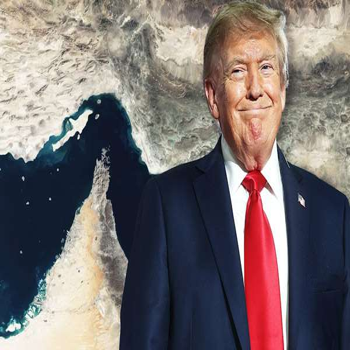


========== PREDICTION ==========
Prediction : Real
Confidence : 99.43%

Class probabilities:
Fake: 0.57%
Real: 99.43%


In [72]:
prediction, confidence = predict_single_image(
    image_path,
    model,
    processor,
    device
)